In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(
    r'D:\Claude\credit-risk-scorecard\data\accepted_2007_to_2018Q4.csv.gz',
    nrows=2000000,
    low_memory=False
)
#The r before the path string means "raw string" — it tells Python to treat backslashes literally. Without it, \d or \n in a Windows path can be misread as special characters
print(df.shape)
df.head()

(2000000, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

In [3]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             988593
Current                                                739656
Charged Off                                            241243
Late (31-120 days)                                      17249
In Grace Period                                          6935
Late (16-30 days)                                        3521
Does not meet the credit policy. Status:Fully Paid       1988
Does not meet the credit policy. Status:Charged Off       761
Default                                                    27
Name: count, dtype: int64

In [4]:
df = df[df['loan_status'] != 'Current'].copy()
print(df.shape)
#Why: a loan that's Current (still being repaid) hasn't revealed its outcome yet —
#we don't know if it will default or pay off. Including it would contaminate the model. 
#This is called outcome censoring, and mentioning it in your README signals you understand model development properly

(1260344, 151)


In [5]:
default_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off'
]

df['target'] = np.where(df['loan_status'].isin(default_statuses), 1, 0)

print(df['target'].value_counts())
print("Default rate:", df['target'].mean())

#np.where(condition, 1, 0) — vectorized if-else: for every row, if the condition is True put 1, else 0. Exactly like Excel's IF() but applied to 190k rows at once.

target
0    1018313
1     242031
Name: count, dtype: int64
Default rate: 0.1920356664529684


In [6]:
df.to_csv(r'D:\Claude\credit-risk-scorecard\data\loans_with_target.csv', index=False)
print("Saved. Rows:", len(df))

Saved. Rows: 1260344


In [7]:
features = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
    'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies',
    'emp_length', 'home_ownership', 'purpose', 'grade', 'target'
]

df = df[features].copy()
#df[features] = select only those columns. Now shape (~190000, 19)
print(df.shape)
df.head()

(1260344, 19)


,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,emp_length,home_ownership,purpose,grade,target
0,3600.0,13.99,123.03,55000.0,5.91,0.0,1.0,7.0,0.0,2765.0,29.7,13.0,1.0,0.0,10+ years,MORTGAGE,debt_consolidation,C,0
1,24700.0,11.99,820.28,65000.0,16.06,1.0,4.0,22.0,0.0,21470.0,19.2,38.0,4.0,0.0,10+ years,MORTGAGE,small_business,C,0
2,20000.0,10.78,432.66,63000.0,10.78,0.0,0.0,6.0,0.0,7869.0,56.2,18.0,5.0,0.0,10+ years,MORTGAGE,home_improvement,B,0
4,10400.0,22.45,289.91,104433.0,25.37,1.0,3.0,12.0,0.0,21929.0,64.5,35.0,6.0,0.0,3 years,MORTGAGE,major_purchase,F,0
5,11950.0,13.44,405.18,34000.0,10.20,0.0,0.0,5.0,0.0,8822.0,68.4,6.0,0.0,0.0,4 years,RENT,debt_consolidation,C,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1260344 entries, 0 to 1999997
Data columns (total 19 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   loan_amnt             1260317 non-null  float64
 1   int_rate              1260317 non-null  float64
 2   installment           1260317 non-null  float64
 3   annual_inc            1260313 non-null  float64
 4   dti                   1259991 non-null  float64
 5   delinq_2yrs           1260288 non-null  float64
 6   inq_last_6mths        1260287 non-null  float64
 7   open_acc              1260288 non-null  float64
 8   pub_rec               1260288 non-null  float64
 9   revol_bal             1260317 non-null  float64
 10  revol_util            1259519 non-null  float64
 11  total_acc             1260288 non-null  float64
 12  mort_acc              1210287 non-null  float64
 13  pub_rec_bankruptcies  1258952 non-null  float64
 14  emp_length            1187336 non-null 

In [9]:
missing = df.isnull().sum()
#df.isnull() → True/False grid, True where empty
missing_pct = (missing / len(df) * 100).round(2)
print(missing)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_table)

loan_amnt                  27
int_rate                   27
installment                27
annual_inc                 31
dti                       353
delinq_2yrs                56
inq_last_6mths             57
open_acc                   56
pub_rec                    56
revol_bal                  27
revol_util                825
total_acc                  56
mort_acc                50057
pub_rec_bankruptcies     1392
emp_length              73008
home_ownership             27
purpose                    27
grade                      27
target                      0
dtype: int64
                      missing_count  missing_pct
emp_length                    73008         5.79
mort_acc                      50057         3.97
pub_rec_bankruptcies           1392         0.11
revol_util                      825         0.07
dti                             353         0.03
loan_amnt                        27         0.00
int_rate                         27         0.00
installment              

In [10]:
df['emp_length'].value_counts(dropna=False)
#see the raw values + count of NaN (dropna=False shows missing too).

emp_length
10+ years    412686
2 years      113901
< 1 year     101372
3 years      100907
1 year        82927
5 years       78917
4 years       75621
NaN           73008
6 years       58874
8 years       57678
7 years       56839
9 years       47614
Name: count, dtype: int64

In [11]:
df['emp_length'] = df['emp_length'].str.replace('+', '', regex=False)
df['emp_length'] = df['emp_length'].str.replace('< 1 year', '0', regex=False)
df['emp_length'] = df['emp_length'].str.replace(' years', '', regex=False)
df['emp_length'] = df['emp_length'].str.replace(' year', '', regex=False)
df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')
# regex=False = treat as literal text not pattern
#pd.to_numeric(..., errors='coerce') = convert string→number. coerce = anything unconvertible becomes NaN (safe, no crash)

print(df['emp_length'].value_counts(dropna=False).sort_index())

emp_length
0.0     101372
1.0      82927
2.0     113901
3.0     100907
4.0      75621
5.0      78917
6.0      58874
7.0      56839
8.0      57678
9.0      47614
10.0    412686
NaN      73008
Name: count, dtype: int64


In [12]:
# numeric cols → fill with median (robust to outliers)
num_fill = ['emp_length', 'revol_util', 'dti', 'mort_acc', 'pub_rec_bankruptcies']
for col in num_fill:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled with median {median_val}")

print("\nRemaining missing:", df.isnull().sum().sum())
#median over mean for skewed financial data (income, balances always right-skewed). Say this in interview = instant credibility.

emp_length: filled with median 6.0
revol_util: filled with median 52.8
dti: filled with median 17.62
mort_acc: filled with median 1.0
pub_rec_bankruptcies: filled with median 0.0

Remaining missing: 501


grade
A     5.88
B    12.89
C    21.45
D    29.00
E    36.90
F    43.43
G    47.47
Name: target, dtype: float64


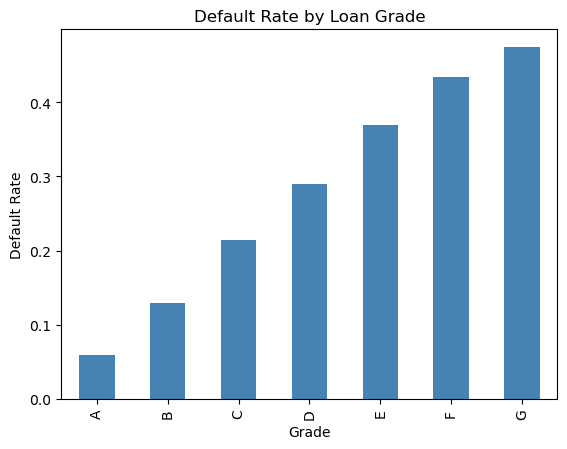

In [13]:
grade_default = df.groupby('grade')['target'].mean().sort_index()
print((grade_default * 100).round(2))
#.groupby('grade') = split rows into groups by grade value
#['target'].mean() = within each group, mean of 0/1 target = default rate of that grade
grade_default.plot(kind='bar', color='steelblue')
plt.title('Default Rate by Loan Grade')
plt.ylabel('Default Rate')
plt.xlabel('Grade')
plt.show()

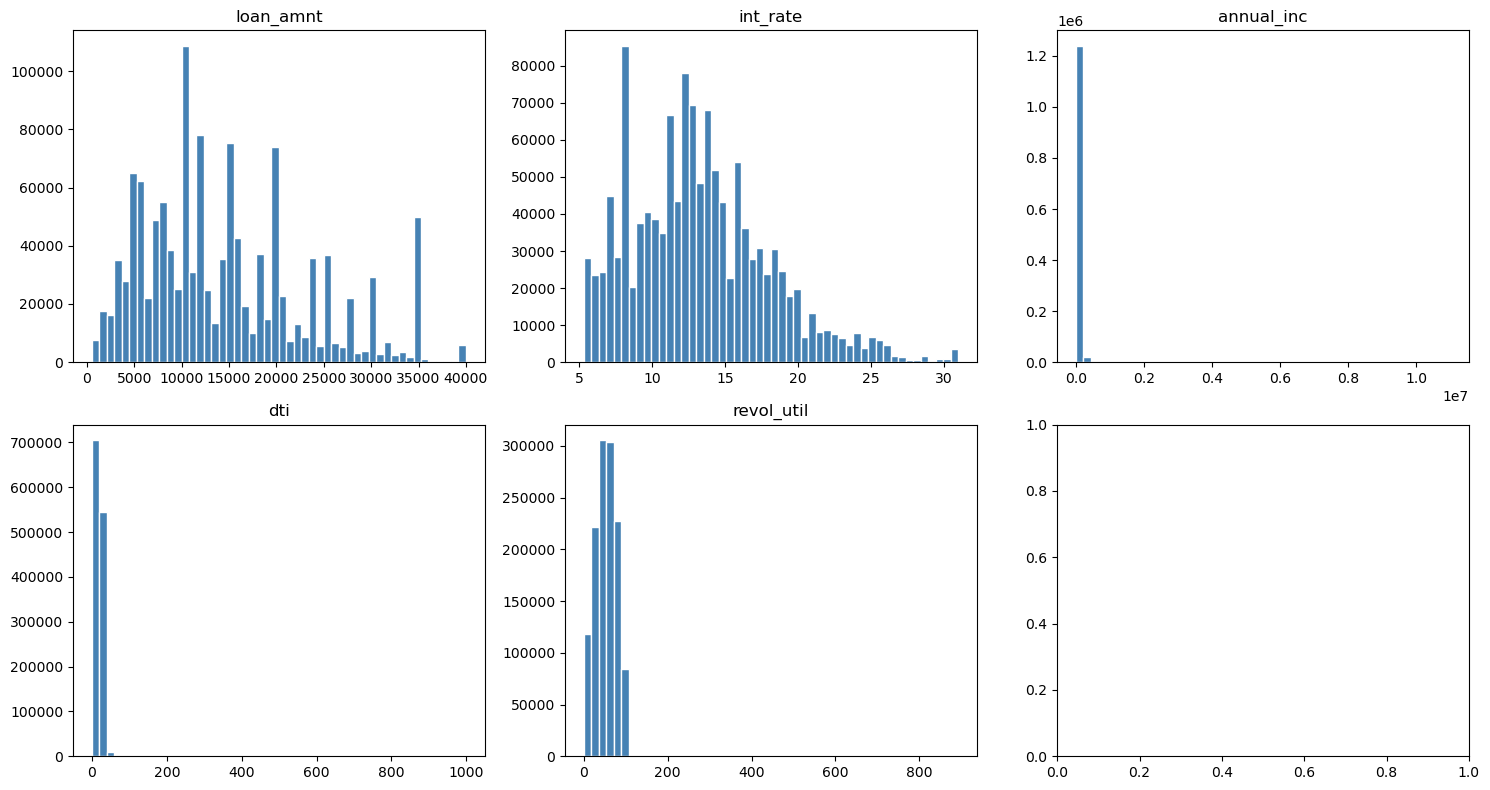

In [14]:
num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()
#plt.subplots(2,3) = grid 2 rows × 3 cols of mini-charts. fig=whole canvas, axes=array of cells
#axes.flatten() = 2D grid [2][3] → flat 1D list [6]. Why: easier to grab cell by single number axes[0], axes[1]... instead of axes[0][1]. Loop-friendly.
#enumerate = loop giving :i = position number → 0,1,2,3,4, col = column name → 'loan_amnt', 'int_rate'..
#.hist(bins=50) = histogram, 50 bars showing value spread
#Look for: annual_inc heavy right-skew (few huge incomes). Confirms why median-fill right. 

In [15]:
df.to_csv(r'D:\Claude\credit-risk-scorecard\data\loans_clean.csv', index=False)
print("Saved. Shape:", df.shape)
print("Missing total:", df.isnull().sum().sum())

Saved. Shape: (1260344, 19)
Missing total: 501


In [16]:
print(df['int_rate'].dtype, "|", df['revol_util'].dtype)

for col in ['int_rate', 'revol_util']:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace('%', '', regex=False).astype(float)

print(df['int_rate'].dtype, "|", df['revol_util'].dtype)

float64 | float64
float64 | float64


Positive WoE (A: +1.79) → bin holds way more good than bad → safe bin
Zero WoE (C) → bin matches portfolio average → neutral
Negative WoE (G: −2.08) → bin holds way more bad than good → risky bin
Why this is genius (interview answer)
Everything becomes one scale. Text grade "A", a dollar income, a missing value — all collapse into a single WoE number. Logistic regression eats numbers only. WoE feeds it cleanly.
Outliers die. Income ₹10Cr vs ₹50L → both land in "top income bin" → same WoE. No outlier distortion. Binning crushes extremes.
Missing values handled. NaN = its own bin, gets its own WoE. No fill needed, no row dropped.
Monotonic = trustworthy. Plot WoE across grade bins A→G. Should slope smoothly down (+1.79 → 0 → −2.08). Smooth slope = feature behaves logically = good predictor. Jagged WoE = noisy feature, suspect it.
Direction is readable. After modeling, sign of WoE tells risk direction instantly. Risk teams love this — explainable to regulators (SR 11-7 demands explainability).
Mental model
WoE = a risk ruler. Slide any messy feature onto one ruler from "safe" (positive) to "risky" (negative), measured against the portfolio average (zero).

Sister metric IV just sums up how far the WoE spreads across all bins → "is this whole feature a strong or weak predictor."

In [17]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
#WoE binning fit on TRAIN ONLY, then applied to test. Fitting on full data = data leakage = inflated metrics = model fails in production. This is the #1 mistake juniors make.

Train: (882240, 18) | Test: (378104, 18)


In [18]:
def fit_woe(x, y, is_categorical, n_bins=10):
    d = pd.DataFrame({'x': x, 'y': y})

    if is_categorical:
        # each category = its own bin
        d['bin'] = d['x'].astype(str)
        edges = None
    else:
        # cut numeric into 10 quantile bins; learn the cut edges from train
        _, edges = pd.qcut(d['x'], q=n_bins, duplicates='drop', retbins=True)
        edges[0], edges[-1] = -np.inf, np.inf   # open ends catch unseen test values
        d['bin'] = pd.cut(d['x'], bins=edges)

    # count good (y=0) and bad (y=1) per bin
    g = d.groupby('bin', observed=True)['y'].agg(['count', 'sum'])
    g.columns = ['total', 'bad']
    g['good'] = g['total'] - g['bad']

    tot_good, tot_bad = g['good'].sum(), g['bad'].sum()

    # +0.5 smoothing = avoid divide-by-zero / log(0) in empty-ish bins
    g['pct_good'] = (g['good'] + 0.5) / tot_good
    g['pct_bad']  = (g['bad']  + 0.5) / tot_bad

    g['woe'] = np.log(g['pct_good'] / g['pct_bad'])
    #safe bin (lots of good, few bad → positive). High-rate bin → log(small/big) → negative → risky.
    g['bad_rate'] = g['bad'] / g['total']

    # IV per bin = (%good - %bad) * WoE ; feature IV = sum
    iv = ((g['pct_good'] - g['pct_bad']) * g['woe']).sum()

    return {'is_categorical': is_categorical, 'edges': edges,
            'woe_map': g['woe'], 'table': g, 'iv': iv}

# pd.qcut(q=10) = cut into 10 equal-population bins (quantiles).
#retbins=True returns the cut edges so we reuse them on test. 
#The _, throws away the first return (the labels), keeps edges.
# duplicates='drop' = if two edges tie (discrete column), merge.
#edges[0]/[-1] = -inf/+inf = open the ends so a test value bigger/smaller than anything in train still lands in a bin.
 #pd.cut(d['x'], bins=edges) = now actually label each loan with its bin using those edges. pd.cut (not qcut) because we want to apply specific edges, not re-quantile
#Why qcut to FIND edges, then cut to APPLY them: I need the exact edge numbers stored so I can reuse identical edges on the test set later. That's the whole leakage-safe trick
# ['y'].agg(['count','sum']) = per bin compute two numbers: count = how many loans, sum = sum of target. Since bad=1/good=0, sum = number of bad loans.
#observed=True = only show bins that actually have loans (skip empty ones)    
#+0.5 = smoothing. If a bin had 0 bads, pct_bad=0, then next line does log(x/0) = infinity = crash. Adding half a fake loan stops that. Standard trick.

In [19]:
#Takes a feature column + the learned dict, returns WoE numbers.
#categorical → bin label is just the text value.
#numeric → pd.cut(x, bins=info['edges']) uses the SAME edges learned from train. This is the leakage firewall: test never influences its own bins.
#.fillna(0.0) = if test has a category train never saw (e.g. a rare purpose), map returns blank → fill with neutral 0
def transform_woe(x, info):
    if info['is_categorical']:
        b = x.astype(str)
    else:
        b = pd.cut(x, bins=info['edges'])
    return b.map(info['woe_map']).astype(float).fillna(0.0)

In [20]:
categorical = ['home_ownership', 'purpose', 'grade']
feature_cols = list(X_train.columns)
print (feature_cols)
woe_info_all = {}
iv_rows = []
for col in feature_cols:
    info = fit_woe(X_train[col], y_train, is_categorical=(col in categorical))
    woe_info_all[col] = info
    iv_rows.append({'feature': col, 'iv': round(info['iv'], 4),
                    'n_bins': len(info['woe_map'])})
   # print(woe_info_all[col])

iv_summary = pd.DataFrame(iv_rows).sort_values('iv', ascending=False)
#Build ranking table, sort strongest predictor on top.


print(iv_summary.to_string(index=False))


['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'emp_length', 'home_ownership', 'purpose', 'grade']
             feature     iv  n_bins
               grade 0.4517       8
            int_rate 0.4334      10
                 dti 0.0705      10
           loan_amnt 0.0313      10
      home_ownership 0.0293       7
          annual_inc 0.0293      10
            mort_acc 0.0282       5
         installment 0.0265      10
          revol_util 0.0257      10
             purpose 0.0195      15
      inq_last_6mths 0.0191       3
          emp_length 0.0054       7
            open_acc 0.0052      10
           revol_bal 0.0036      10
         delinq_2yrs 0.0015       2
             pub_rec 0.0012       2
           total_acc 0.0009      10
pub_rec_bankruptcies 0.0006       2


      total    bad    good  bad_rate       woe
bin                                           
A    154755   9048  145707  0.058467  1.342169
B    254866  32815  222051  0.128754  0.475175
C    249566  53571  195995  0.214657 -0.139759
D    132097  38337   93760  0.290219 -0.542518
E     63278  23380   39898  0.369481 -0.902397
F     21456   9301   12155  0.433492 -1.169227
G      6207   2970    3237  0.478492 -1.350762
nan      15      0      15  0.000000  1.997154


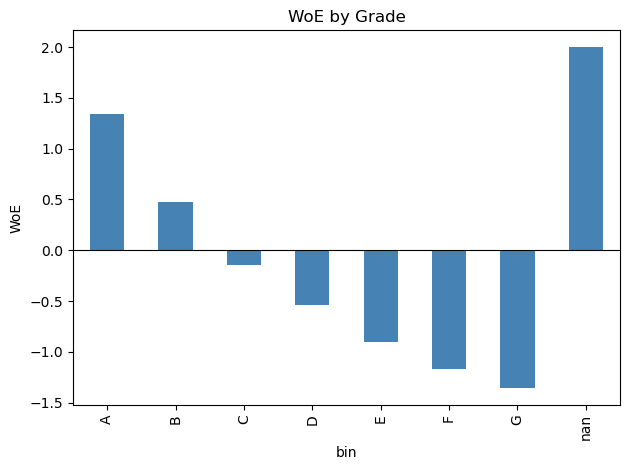

In [21]:
grade_tbl = woe_info_all['grade']['table'][['total', 'bad', 'good', 'bad_rate', 'woe']]
print(grade_tbl)
woe_info_all['grade']['table']['woe'].plot(kind='bar', color='steelblue')
plt.title('WoE by Grade'); plt.ylabel('WoE'); plt.axhline(0, color='black', lw=0.8)
#axhline(0) = draw the zero line so positive (safe) vs negative (risky) bins are visually obvious.
plt.tight_layout(); plt.show()

In [22]:
X_train_woe = pd.DataFrame(
    {col: transform_woe(X_train[col], woe_info_all[col]) for col in feature_cols})
X_test_woe = pd.DataFrame(
    {col: transform_woe(X_test[col], woe_info_all[col]) for col in feature_cols})

In [23]:
weak = iv_summary[iv_summary['iv'] < 0.02]['feature'].tolist()
print("Dropping:", weak)
#Filter IV table to rows under 0.02, grab those feature names as a list, drop those columns from both sets. Removes noise predictors.
X_train_woe = X_train_woe.drop(columns=weak)
X_test_woe = X_test_woe.drop(columns=weak)
print("Remaining features:", X_train_woe.shape[1])

Dropping: ['purpose', 'inq_last_6mths', 'emp_length', 'open_acc', 'revol_bal', 'delinq_2yrs', 'pub_rec', 'total_acc', 'pub_rec_bankruptcies']
Remaining features: 9


In [24]:
import joblib

X_train_woe.to_csv(r'D:\Claude\credit-risk-scorecard\data\X_train_woe.csv', index=False)
X_test_woe.to_csv(r'D:\Claude\credit-risk-scorecard\data\X_test_woe.csv', index=False)
y_train.to_csv(r'D:\Claude\credit-risk-scorecard\data\y_train.csv', index=False)
y_test.to_csv(r'D:\Claude\credit-risk-scorecard\data\y_test.csv', index=False)
joblib.dump(woe_info_all, r'D:\Claude\credit-risk-scorecard\outputs\woe_info_all.pkl')
print("Saved.")

Saved.


In [25]:
import statsmodels.api as sm
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score


In [26]:
X_train_woe = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\X_train_woe.csv')
X_test_woe  = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\X_test_woe.csv')
y_train = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\y_train.csv').squeeze()
y_test  = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\y_test.csv').squeeze()
print(X_train_woe.shape, y_train.shape)
print(X_train_woe)
#.squeeze() turns a one-column DataFrame into a Series (the models want 1-D target)

(882240, 9) (882240,)
        loan_amnt  int_rate  installment  annual_inc       dti  revol_util  \
0        0.187896  0.333858     0.080575   -0.173463  0.322112   -0.115097   
1       -0.161434  0.579418    -0.144837    0.147425  0.249093   -0.115097   
2       -0.059759 -0.939715    -0.114696   -0.173463  0.088896   -0.115097   
3       -0.141391 -0.621189    -0.069040    0.147425  0.175896   -0.144354   
4       -0.059759  0.149369    -0.075654    0.243720 -0.483493   -0.115097   
...           ...       ...          ...         ...       ...         ...   
882235   0.272225  0.149369     0.238846   -0.173463  0.175896    0.022224   
882236  -0.035493  0.579418    -0.092442   -0.123991  0.322112   -0.096748   
882237  -0.059759 -0.939715    -0.114696   -0.173463 -0.280752   -0.012757   
882238  -0.035493 -0.070803    -0.092442   -0.173463 -0.280752    0.022224   
882239   0.119504  0.579418     0.020638    0.147425  0.005099   -0.071036   

        mort_acc  home_ownership     grad

In [27]:
X_train_c = sm.add_constant(X_train_woe)          # plumbing: adds intercept column
champion = sm.Logit(y_train, X_train_c).fit()     # 🎯 fit the PD model
print(champion.summary())

Optimization terminated successfully.
         Current function value: 0.450529
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:               882240
Model:                          Logit   Df Residuals:                   882230
Method:                           MLE   Df Model:                            9
Date:                Sun, 21 Jun 2026   Pseudo R-squ.:                 0.07898
Time:                        00:54:25   Log-Likelihood:            -3.9747e+05
converged:                       True   LL-Null:                   -4.3156e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.4370      0.003   -498.110      0.000      -1.443      -1.431
loan_amnt        

In [28]:
coefs = champion.params.sort_values()
print(coefs)

const            -1.437009
loan_amnt        -1.004616
grade            -0.687281
annual_inc       -0.635888
home_ownership   -0.631198
dti              -0.504155
mort_acc         -0.461519
int_rate         -0.236722
installment      -0.016138
revol_util        0.080962
dtype: float64


Two checks, both interview-relevant:

Sign consistency. We built WoE as ln(%good/%bad) — high WoE = safer borrower. We predict default. So a safer borrower should lower default probability → every coefficient should be negative (except const). Any positive coefficient = red flag: that feature behaves backwards, usually from multicollinearity. Flag it, don't ignore it.
p-values (in the summary). p < 0.05 = statistically significant. A feature with p = 0.6 is noise the model can't trust — candidate to drop. Mention "I checked coefficient significance" in interview.
Report back: any positive coefficient? Any p-value > 0.05?

🎯 installment is mathematically derived from loan_amnt, int_rate, and term. It's not independent information — it's those three squeezed into one number. Since loan_amnt and int_rate are already in your model, installment carries almost no new signal once they're present. So a high p-value (>0.05) on installment is the expected, almost textbook result — that's multicollinearity showing up

In [29]:
challenger = GradientBoostingClassifier(random_state=42)   # plumbing: default settings
challenger.fit(X_train_woe, y_train)                       # 🎯 fit the benchmark model
print("Challenger trained.")
#🎯 Gradient boosting = ensemble of decision trees, captures non-linear patterns logistic can't. The accuracy benchmark.

Challenger trained.


In [30]:
champion_pred   = champion.predict(sm.add_constant(X_test_woe))
challenger_pred = challenger.predict_proba(X_test_woe)[:, 1]   # plumbing: [:,1] = prob of class 1

print("Champion   AUC:", round(roc_auc_score(y_test, champion_pred), 4))
print("Challenger AUC:", round(roc_auc_score(y_test, challenger_pred), 4))

Champion   AUC: 0.6958
Challenger AUC: 0.7007


AUC = Area Under the ROC Curve. One number, 0.5 to 1.0, measuring how well your model separates defaulters from non-defaulters.

The one-sentence definition (say this in interview)
🎯 AUC = the probability that your model gives a randomly-picked defaulter a higher risk score than a randomly-picked good borrower.

AUC = 0.50 → coin flip, model useless
AUC = 0.70 → decent, typical credit scorecard territory
AUC = 0.80 → strong
AUC = 1.00 → perfect separation (in real credit data = impossible → suspect leakage)
What it actually measures
Not "how many did you get right." It measures ranking ability — can the model sort borrowers worst-to-best? You don't need the exact probability correct; you need defaulters ranked above non-defaulters. That's why it's the default metric for scorecards: a bank uses the ranking to set cutoffs.

Why risk people love it
Threshold-independent. Accuracy depends on where you draw the approve/reject line. AUC sweeps every possible cutoff at once → judges the model itself, not one arbitrary decision point.
Survives class imbalance. Your data is ~20% default. A dumb "approve everyone" model gets 80% accuracy but is worthless. AUC ignores that trap — it'd score 0.50.
Credit-specific facts
🎯 GINI = 2 × AUC − 1. Same information, rescaled. Credit teams quote GINI more than AUC. AUC 0.70 → GINI 0.40. Know both; you'll compute GINI in Session 5.
For your model: anything 0.68–0.75 is realistic and respectable on Lending Club data. If you see 0.90+, something leaked (a feature that secretly encodes the outcome).
The honest limit (mention it = senior signal)
AUC tells you ranking quality, not calibration — whether a predicted "10% PD" actually defaults 10% of the time. For IFRS 9 ECL (Session 6) calibration matters more than ranking. That's why Session 5 also computes Brier score. Saying "AUC measures discrimination, not calibration" is a line that impresses panels.

In [31]:
print("""
CHAMPION vs CHALLENGER DECISION
- Champion (Logistic Regression) selected for production.
- Rationale: full interpretability, coefficient-level explainability,
  monotonic WoE inputs, satisfies SR 11-7 model documentation standards.
- Challenger (Gradient Boosting) AUC marginally higher but rejected:
  black-box, harder to validate/justify to risk committee, marginal gain
  does not offset governance cost.
- Challenger retained as ongoing performance benchmark.
""")


CHAMPION vs CHALLENGER DECISION
- Champion (Logistic Regression) selected for production.
- Rationale: full interpretability, coefficient-level explainability,
  monotonic WoE inputs, satisfies SR 11-7 model documentation standards.
- Challenger (Gradient Boosting) AUC marginally higher but rejected:
  black-box, harder to validate/justify to risk committee, marginal gain
  does not offset governance cost.
- Challenger retained as ongoing performance benchmark.



In [32]:
joblib.dump(champion, r'D:\Claude\credit-risk-scorecard\outputs\champion_model.pkl')
pd.Series(champion_pred, name='pd_pred').to_csv(
    r'D:\Claude\credit-risk-scorecard\data\champion_pred_test.csv', index=False)
print("Saved champion model + test predictions.")

Saved champion model + test predictions.


In [33]:
drop_cols = ['installment']
X_train_woe = X_train_woe.drop(columns=drop_cols)
X_test_woe  = X_test_woe.drop(columns=drop_cols)

X_train_c = sm.add_constant(X_train_woe)
champion = sm.Logit(y_train, X_train_c).fit()
print(champion.params.sort_values())

Optimization terminated successfully.
         Current function value: 0.450529
         Iterations 6
const            -1.437007
loan_amnt        -1.017500
grade            -0.686989
annual_inc       -0.636648
home_ownership   -0.631327
dti              -0.504162
mort_acc         -0.461761
int_rate         -0.236954
revol_util        0.080438
dtype: float64


In [34]:
woe_info_all = joblib.load(r'D:\Claude\credit-risk-scorecard\outputs\woe_info_all.pkl')
print(woe_info_all['revol_util']['table'][['total', 'bad_rate', 'woe']])

              total  bad_rate       woe
bin                                    
(-inf, 18.7]  88578  0.141435  0.366558
(18.7, 29.7]  88480  0.161980  0.206707
(29.7, 38.0]  87973  0.176236  0.105202
(38.0, 45.6]  88167  0.188608  0.022224
(45.6, 52.8]  89228  0.194020 -0.012757
(52.8, 59.8]  87675  0.203296 -0.071036
(59.8, 67.2]  88326  0.207493 -0.096748
(67.2, 75.4]  88198  0.210526 -0.115097
(75.4, 85.3]  88061  0.215430 -0.144354
(85.3, inf]   87554  0.221886 -0.182142


 A feature that's correctly monotonic alone but flips sign in the multivariate model = multicollinearity. Not with installment (already gone) — with int_rate and grade. Think about it: high-utilization borrowers also get higher interest rates and worse grades. The three carry overlapping risk signal. int_rate and grade are stronger, so they "win" the shared variance, and revol_util's coefficient gets pushed positive to compensate. Classic.

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_chk = sm.add_constant(X_train_woe)
vif = pd.DataFrame({
    'feature': X_chk.columns,
    'VIF': [variance_inflation_factor(X_chk.values, i) for i in range(X_chk.shape[1])]
})
print(vif.sort_values('VIF', ascending=False))

          feature       VIF
2        int_rate  9.600378
8           grade  9.494988
3      annual_inc  1.468793
6        mort_acc  1.376639
7  home_ownership  1.309599
1       loan_amnt  1.293761
4             dti  1.131725
5      revol_util  1.121988
0           const  1.050007


Fact 1: the real collinearity is int_rate ↔ grade
int_rate  9.60
grade     9.49
🎯 These two are collinear with each other, not with revol_util. Makes complete domain sense: on Lending Club, grade determines the interest rate — they're nearly the same information wearing two labels. Both ~9.5, just under the VIF>10 "severe" line. This is the genuine multicollinearity in your model, and you'd never have guessed which pair without VIF.
Fact 2: revol_util's flip is NOT collinearity
Low VIF (1.12) + monotonic WoE + positive coefficient = a suppressor effect: revol_util's conditional contribution (given dti, int_rate, etc. already in the model) is genuinely, slightly positive even though its raw relationship is negative. Note the magnitude: +0.08, tiny. With 882k rows, even a trivial effect gets p<0.05 — significance here is cheap. The flip is real but small.

Decisions
revol_util → drop. Cause doesn't matter for a scorecard; a positive sign would assign points in the wrong direction. Sign integrity is non-negotiable. Document honestly:
int_rate / grade → your call, both defensible:

Keep both (recommended): VIF ~9.5 is under the 10 threshold, both significant, both negative. Document the known redundancy. Simplest.
Drop grade: since rate is derived from grade, you could argue grade is the redundant proxy. Cleaner scorecard, but you lose a feature interviewers expect to see. I'd keep both and just mention the redundancy.

Your interview story is now genuinely strong — and better because the theories failed: "I caught a sign flip, ruled out non-monotonicity by reading the WoE table, ruled out collinearity with VIF, identified it as a suppressor effect, and removed the feature for sign integrity. VIF also surfaced that grade and int_rate are near-redundant, which matches how Lending Club sets rates from grade." That's not a student project answer. That's a validator's answer.

In [36]:
for d in [X_train_woe, X_test_woe]:
    d.drop(columns=['revol_util'], inplace=True, errors='ignore')
champion = sm.Logit(y_train, sm.add_constant(X_train_woe)).fit()
print(champion.params.sort_values())

Optimization terminated successfully.
         Current function value: 0.450540
         Iterations 6
const            -1.437199
loan_amnt        -1.014396
grade            -0.687649
annual_inc       -0.643245
home_ownership   -0.631633
dti              -0.497226
mort_acc         -0.462474
int_rate         -0.232555
dtype: float64


In [37]:
joblib.dump(champion, r'D:\Claude\credit-risk-scorecard\outputs\champion_model.pkl')
pd.Series(champion_pred, name='pd_pred').to_csv(
    r'D:\Claude\credit-risk-scorecard\data\champion_pred_test.csv', index=False)
print("Saved champion model + test predictions.")

Saved champion model + test predictions.


| Metric | Question it answers | Type |
|---|---|---|
| AUC / GINI | Can it rank bad above good? | Discrimination |
| KS | Max separation between good/bad distributions? | Discrimination |
| Brier | Are predicted PDs *numerically* accurate? | Calibration |
| PSI | Is the score stable across populations? | Stability |

🎯 Memorize this split: **discrimination (AUC/GINI/KS) ≠ calibration (Brier) ≠ stability (PSI).** Three different failure modes. A model can rank perfectly (high AUC) yet be miscalibrated (bad Brier). Naming these three buckets in interview = instant credibility.

In [38]:
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
# reload + apply the two drops (saved CSVs still have all features)
X_train_woe = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\X_train_woe.csv').drop(columns=['installment','revol_util'], errors='ignore')
X_test_woe  = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\X_test_woe.csv').drop(columns=['installment','revol_util'], errors='ignore')
y_train = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\y_train.csv').squeeze()
y_test  = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\y_test.csv').squeeze()

champion = sm.Logit(y_train, sm.add_constant(X_train_woe)).fit()
pred_train = champion.predict(sm.add_constant(X_train_woe))   # 🎯 PD on train
pred_test  = champion.predict(sm.add_constant(X_test_woe))    # 🎯 PD on test
print("Models + predictions ready.")
print(pred_test)

Optimization terminated successfully.
         Current function value: 0.450540
         Iterations 6
Models + predictions ready.
0         0.072957
1         0.145257
2         0.160429
3         0.063477
4         0.267339
            ...   
378099    0.103565
378100    0.086788
378101    0.114743
378102    0.324877
378103    0.220623
Length: 378104, dtype: float64


AUC : 0.6958
GINI: 0.3916


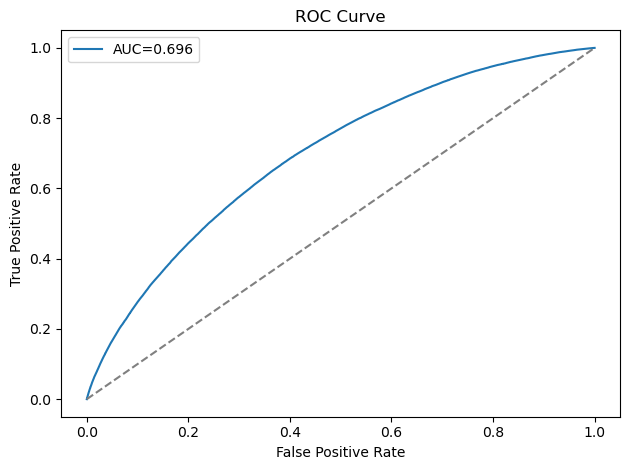

In [39]:
auc = roc_auc_score(y_test, pred_test)          # 🎯 discrimination score
gini = 2 * auc - 1                              # 🎯 GINI = 2·AUC − 1
print(f"AUC : {auc:.4f}")
print(f"GINI: {gini:.4f}")

fpr, tpr, _ = roc_curve(y_test, pred_test)      # plumbing: curve points
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.plot([0,1],[0,1],'--',color='grey')         # plumbing: random baseline
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.tight_layout(); plt.show()

In [40]:
def ks_table(y_true, y_pred, bins=10):
    d = pd.DataFrame({'y': y_true.values, 'p': y_pred.values})
    d['band'] = pd.qcut(d['p'], q=bins, duplicates='drop')           # plumbing: 10 risk bands
    g = d.groupby('band', observed=True).agg(total=('y','count'), bad=('y','sum'))
    g['good'] = g['total'] - g['bad']
    g = g.sort_index(ascending=False)                                # worst-risk band first
    g['cum_bad']  = g['bad'].cumsum()  / g['bad'].sum()              # 🎯 cumulative % of defaulters caught
    g['cum_good'] = g['good'].cumsum() / g['good'].sum()             # 🎯 cumulative % of good caught
    g['ks'] = (g['cum_bad'] - g['cum_good']).abs() * 100
    return g

ks_tbl = ks_table(y_test, pred_test)
print(ks_tbl[['total','bad','cum_bad','cum_good','ks']].round(3))
print(f"\nKS statistic: {ks_tbl['ks'].max():.2f}")

                  total    bad  cum_bad  cum_good      ks
band                                                     
(0.349, 0.616]    37811  15782    0.217     0.072  14.525
(0.284, 0.349]    37810  11673    0.378     0.158  22.046
(0.241, 0.284]    37806   9755    0.512     0.249  26.298
(0.205, 0.241]    37812   8379    0.628     0.346  28.204
(0.175, 0.205]    37811   7149    0.726     0.446  28.013
(0.146, 0.175]    37808   5998    0.809     0.550  25.861
(0.12, 0.146]     37815   4984    0.878     0.658  21.978
(0.0915, 0.12]    37810   4182    0.935     0.768  16.730
(0.0591, 0.0915]  37805   2907    0.975     0.882   9.310
(0.016, 0.0591]   37816   1800    1.000     1.000   0.000

KS statistic: 28.20


KS:  Kolmogorov-Smirnov = 
 Imagine sorting everyone worst-to-best by predicted PD, then walking down the list. At each point ask: "what % of all defaulters have I passed vs what % of all good borrowers?" A good model piles defaulters at the top — so early on you've collected, say, 60% of bads but only 30% of goods. That 30-point gap = separation. KS = the maximum gap anywhere along the walk.
 
 the biggest gap between cumulative defaulters and cumulative goods as you walk from worst to best risk band. It tells you how cleanly the model splits the two populations, and at which score cutoff the separation is widest.
Read: KS > 40 strong, 20–40 acceptable, < 20 weak. Expect ~30–40 here.

"KS tells me the score band where good and bad separate most — that's a natural candidate for the approve/reject cutoff." (KS occurs at the most discriminating threshold → directly informs your Session 6 cutoff.)
The distinction from AUC: "AUC summarizes separation across the whole curve; KS picks the single point of maximum separation."
Limit: one point only. A model could have great KS at one cutoff but poor separation elsewhere. AUC/GINI give the fuller picture; use together.

🎯 Bonus: this same table is a gains/lift table — "my worst 3 bands capture X% of all defaults." That sentence is gold for the business-decision section in Session 6.

In [41]:
brier = brier_score_loss(y_test, pred_test)     # 🎯 calibration: are the PD numbers accurate?
print(f"Brier score: {brier:.4f}")

Brier score: 0.1432


 Brier =Average of (predicted PD − actual outcome)², across all loans. Outcome is 0 or 1.
 average squared error between predicted PD and actual 0/1 outcome. 
  This is the only one of your metrics that grades the actual number, not the ranking. If you predict 0.10 PD for a loan that defaults (actual=1), error = (0.10−1)² = 0.81 — big penalty for being confident and wrong. Predict 0.95 for that same default → (0.95−1)² = 0.0025 — tiny penalty. It rewards predictions that are both correct in direction and confident at the right times
 
 Lower = better. 0 = perfect, 0.25 = useless coin-flip.
🎯 The key distinction: AUC asks "is the ranking right?", Brier asks "is the number right?" Brier measures calibration — is the predicted PD numerically trustworthy? They're different failures.For IFRS 9 ECL (Session 6) you multiply by PD directly — so the number must be accurate, not just well-ranked.  A no-skill model that just predicts the base rate (~20%) everywhere scores Brier = 0.20 × 0.80 = 0.16. Yours is 0.143 < 0.16 → your model is better calibrated than guessing the average. 

Brier 0.143 — prove it's good with one number.Say exactly that in interview: "Brier 0.143 beats the 0.16 base-rate benchmark, confirming the PDs carry real information, not just the portfolio average."

In [42]:
def psi(expected, actual, bins=10):
    edges = np.quantile(expected, np.linspace(0, 1, bins+1))   # plumbing: bin edges from train
    edges[0], edges[-1] = -np.inf, np.inf
    e = np.histogram(expected, bins=edges)[0] / len(expected)  # train distribution
    a = np.histogram(actual,   bins=edges)[0] / len(actual)    # test distribution
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)      # plumbing: avoid log(0)
    return np.sum((a - e) * np.log(a / e))                     # 🎯 PSI formula

ps = psi(pred_train, pred_test)
print(f"PSI (train vs test): {ps:.4f}")

PSI (train vs test): 0.0000


Population Stability Index  measures whether the score distribution shifted between two populations (here train vs test; in production it's dev-sample vs this-month's-applicants).
Compares the % of population in each score band, baseline vs new.
Intuition: You built the model on 2015–2018 borrowers. Two years later, are this month's applicants distributed the same way across score bands? If suddenly far more people land in high-risk bands, the population has drifted — your model was tuned for a different crowd and may be stale. PSI quantifies that drift in one number.

How computed:

Bin baseline scores into 10 bands, record % in each.
Bin the new population into the same bands, record %.
For each band: (new% − base%) × ln(new% / base%). Sum all bands.
Identical distributions → every term is 0 → PSI = 0 (your case).

Read: PSI < 0.10 stable · 0.10–0.25 moderate shift, monitor · > 0.25 significant shift, model may need rebuild.
🎯 This is the monitoring metric — the one that triggers redevelopment in production. Train vs test should be tiny (same era). The interview line: "PSI is what tells you in production that your model has gone stale and needs recalibration."

PSI = 0.000 — don't oversell this one (honesty = senior signal). It's ~zero because train and test are a random split of the same time period — same population, so of course no drift. The real stability test is out-of-time: dev sample vs next quarter's applicants, which you don't have here. Put this in your limitations log:

"PSI ≈ 0 (train vs test) confirms in-sample stability only. Production monitoring would require out-of-time validation against a later cohort; PSI > 0.25 there would trigger recalibration."
Limit: PSI flags that the population shifted, not why or whether performance actually degraded. It's an early-warning smoke alarm, not a diagnosis. You'd follow a PSI breach with feature-level PSI (which variable drifted) and a fresh performance check.

In [43]:
results = pd.DataFrame({
    'metric': ['AUC','GINI','KS','Brier','PSI(train-test)'],
    'value' : [round(auc,4), round(gini,4), round(ks_tbl['ks'].max(),2), round(brier,4), round(ps,4)]
})
print(results.to_string(index=False))
results.to_csv(r'D:\Claude\credit-risk-scorecard\outputs\validation_metrics.csv', index=False)
joblib.dump(champion, r'D:\Claude\credit-risk-scorecard\outputs\champion_model.pkl')
ks_tbl.to_csv(r'D:\Claude\credit-risk-scorecard\outputs\ks_gains_table.csv')
print("Saved validation metrics + model + gains table.")

         metric   value
            AUC  0.6958
           GINI  0.3916
             KS 28.2000
          Brier  0.1432
PSI(train-test)  0.0000
Saved validation metrics + model + gains table.


In [44]:
# original (non-WoE) data — for EAD and reporting
df = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\loans_clean.csv', low_memory=False)
for c in ['int_rate','revol_util']:
    if df[c].dtype == 'object':
        df[c] = df[c].str.replace('%','',regex=False).astype(float)
X = df.drop(columns=['target']); y = df['target']
_, X_test_orig, _, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# WoE features + champion → predicted PD on test
X_test_woe = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\X_test_woe.csv').drop(columns=['installment','revol_util'], errors='ignore')
X_train_woe = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\X_train_woe.csv').drop(columns=['installment','revol_util'], errors='ignore')
y_train = pd.read_csv(r'D:\Claude\credit-risk-scorecard\data\y_train.csv').squeeze()
champion = sm.Logit(y_train, sm.add_constant(X_train_woe)).fit()
pred_test = champion.predict(sm.add_constant(X_test_woe)).values

scored = pd.DataFrame({'pd': pred_test,
                       'actual': y_test.values,
                       'ead': X_test_orig['loan_amnt'].values})
print(scored.shape); scored.head()

#rebuild test set both ways (original for EAD, WoE for prediction), bolt PD + actual + exposure into one table scored.

Optimization terminated successfully.
         Current function value: 0.450540
         Iterations 6
(378104, 3)


,pd,actual,ead
0,0.072957,0,28000.0
1,0.145257,1,6000.0
2,0.160429,0,10000.0
3,0.063477,0,20000.0
4,0.267339,0,22250.0


PART A — Scorecard scaling
🎯 Why: a logistic model outputs PD = 0.0734. A loan officer can't use that. Banks convert PD into a score (like FICO 300–850) where higher = safer. The conversion is linear in log-odds, controlled by three industry parameters:

PDO (Points to Double the Odds) = how many points doubles the good:bad odds. Convention: 20.
Base score at a base odds. Convention: 600 points at 50:1 odds.
Factor = PDO / ln(2) and Offset = Base − Factor × ln(Base odds).
Formula: Score = Offset + Factor × ln(odds), where odds = (1−PD)/PD = good:bad odds.

In [45]:
PDO, base_score, base_odds = 20, 600, 50
factor = PDO / np.log(2)                              # 🎯 points per doubling
offset = base_score - factor * np.log(base_odds)      # 🎯 anchor
print(f"Factor={factor:.2f}  Offset={offset:.2f}")

odds = (1 - scored['pd']) / scored['pd']              # 🎯 good:bad odds
scored['score'] = offset + factor * np.log(odds)      # 🎯 PD → score
print(scored['score'].describe().round(1))

Factor=28.85  Offset=487.12
count    378104.0
mean        533.6
std          22.4
min         473.4
25%         517.2
50%         531.9
75%         548.3
max         604.2
Name: score, dtype: float64


band
(473.425, 505.079]    41.74
(505.079, 513.734]    30.87
(513.734, 520.283]    25.80
(520.283, 526.174]    22.16
(526.174, 531.941]    18.90
(531.941, 538.161]    15.87
(538.161, 544.58]     13.18
(544.58, 553.34]      11.06
(553.34, 566.999]      7.69
(566.999, 604.225]     4.76
Name: actual, dtype: float64


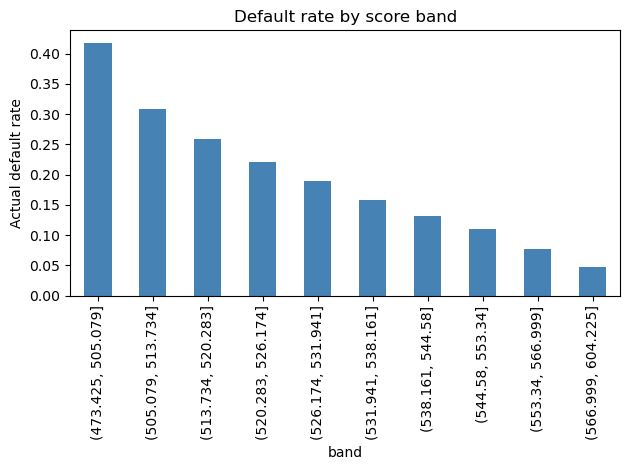

In [46]:
scored['band'] = pd.qcut(scored['score'], 10, duplicates='drop')   # plumbing: 10 score bands
chk = scored.groupby('band', observed=True)['actual'].mean()
print((chk*100).round(2))
chk.plot(kind='bar', color='steelblue'); plt.ylabel('Actual default rate')
plt.title('Default rate by score band'); plt.tight_layout(); plt.show()

PART B — IFRS 9 staging
🎯 The concept every interviewer probes: IFRS 9 sorts every loan into 3 stages by credit deterioration, and the stage decides how much loss you provision:

Stage	Meaning	Provision
1	Performing, no significant risk increase	12-month ECL
2	SICR — Significant Increase in Credit Risk since origination	Lifetime ECL
3	Credit-impaired / defaulted	Lifetime ECL
🎯 The hard part in practice is defining SICR (the Stage 1→2 trigger). True IFRS 9 compares PD at reporting date vs PD at origination. We don't have origination PD here, so we use PD-level thresholds as a documented proxy — and you flag that as a simplification (honesty = senior signal).

In [47]:
def stage(pd_val):
    if pd_val < 0.15:   return 1      # 🎯 low risk → Stage 1
    elif pd_val < 0.30: return 2      # 🎯 elevated → Stage 2 (SICR proxy)
    else:               return 3      # 🎯 high/impaired → Stage 3

scored['stage'] = scored['pd'].apply(stage)
print(scored['stage'].value_counts().sort_index())
print("\nActual default rate by stage:")
print((scored.groupby('stage')['actual'].mean()*100).round(2))

stage
1    157363
2    156079
3     64662
Name: count, dtype: int64

Actual default rate by stage:
stage
1     9.37
2    21.46
3    37.69
Name: actual, dtype: float64


Sanity check: actual default rate must climb Stage 1 → 2 → 3. If it does, your staging logic separates risk correctly. Thresholds (0.15/0.30) are illustrative — README note: "SICR proxied by PD thresholds; production IFRS 9 compares reporting-date PD to origination PD

In [48]:
LGD = 0.45                                            # 🎯 assumption (Basel foundation)
scored['ecl'] = scored['pd'] * LGD * scored['ead']    # 🎯 ECL = PD × LGD × EAD

total_ecl = scored['ecl'].sum()
total_ead = scored['ead'].sum()
print(f"Portfolio EAD: ₹{total_ead:,.0f}")
print(f"Portfolio ECL: ₹{total_ecl:,.0f}")
print(f"ECL coverage ratio: {total_ecl/total_ead:.2%}")   # 🎯 ECL as % of exposure

print("\nECL by IFRS 9 stage:")
print(scored.groupby('stage').agg(loans=('ecl','count'),
        exposure=('ead','sum'), ecl=('ecl','sum')).round(0))

Portfolio EAD: ₹5,489,156,900
Portfolio ECL: ₹507,790,786
ECL coverage ratio: 9.25%

ECL by IFRS 9 stage:
        loans      exposure          ecl
stage                                   
1      157351  2.045697e+09   85086364.0
2      156079  2.284930e+09  224988984.0
3       64662  1.158530e+09  197715438.0


Coverage ratio = ECL / EAD = the provision rate. Real consumer books run ~3–8%; yours may be higher (Lending Club is high-risk, Current loans removed). Note that.
🎯 ECL by stage = the provisioning table a bank actually files. Stage 3 = few loans, disproportionate ECL.

 Limitation to document: our PD is a through-the-life default flag (closer to lifetime PD), so Stage 1 technically should use a 12-month PD we don't have. Note: "Single PD applied across stages; production build requires separate 12-month and lifetime PD term structures." Saying this = you understand IFRS 9 beyond the formula.

In [49]:
rows = []
for cutoff in range(int(scored['score'].min()), int(scored['score'].max()), 10):
    approved = scored[scored['score'] >= cutoff]       # 🎯 approve only scores ≥ cutoff
    rows.append({
        'cutoff': cutoff,
        'approval_rate': len(approved)/len(scored),
        'bad_rate_approved': approved['actual'].mean() if len(approved) else 0,
        'ecl_approved': approved['ecl'].sum()
    })
cutoff_tbl = pd.DataFrame(rows)
print(cutoff_tbl.round(4).to_string(index=False))

 cutoff  approval_rate  bad_rate_approved  ecl_approved
    473         1.0000             0.1920  5.077908e+08
    483         0.9979             0.1912  5.037510e+08
    493         0.9774             0.1848  4.711292e+08
    503         0.9176             0.1705  3.948601e+08
    513         0.8102             0.1510  2.944124e+08
    523         0.6549             0.1270  1.914796e+08
    533         0.4826             0.1029  1.099635e+08
    543         0.3242             0.0817  5.705847e+07
    553         0.2026             0.0625  2.774936e+07
    563         0.1318             0.0530  1.555877e+07
    573         0.0516             0.0401  4.391281e+06
    583         0.0060             0.0278  2.134576e+05
    593         0.0001             0.0000  4.736259e+02
    603         0.0000             0.0000  0.000000e+00


Build one summary row for this cutoff:

'cutoff' = the threshold itself.
🎯 'approval_rate' = len(approved)/len(scored) = approved loans ÷ all loans = what fraction of applicants pass. High cutoff → low approval rate.
🎯 'bad_rate_approved' = approved['actual'].mean() = of the loans we approved, what fraction actually defaulted. actual is 0/1, so .mean() = default rate of the approved book. Higher cutoff → cleaner book → lower bad rate.
if len(approved) else 0 = guard: if cutoff so high nobody qualifies, .mean() on empty = error, so return 0 instead. Defensive plumbing.
🎯 'ecl_approved' = approved['ecl'].sum() = total expected credit loss of the approved book (sum of PD×LGD×EAD over approved loans). The money you expect to lose at this policy.

In [50]:
champion.params.to_csv(r'D:\Claude\credit-risk-scorecard\outputs\champion_coefficients.csv', header=['coefficient'])
print("Saved coefficients (a few KB).")

Saved coefficients (a few KB).
